In [1]:
import pandas as pd 
import numpy as np 

In [2]:
df = pd.read_csv("Garment_Job_Risk_bulk_dataset.csv")
df.head(10)
df.tail(10)

,Name,Garment_Name,Experience_Years,Job_Role,Working_Hours_Per_Week,Exposure_To_Chemicals,Machine_Use,Workstation_Ergonomics,Injury_History,Health_Condition,Safety_Training,Shift_Type,Task_Rotation_Frequency,Job_Risk
2490,Rasel Hossain,Pallmall Group,3,Dyeing,52,Medium,NaN,Average,0,Healthy,Basic,Day,Occasional,Medium
2491,Mariam Noor,Pallmall Group,23,Sewing,40,Low,Light,Poor,1,Healthy,Basic,Day,Frequent,Medium
2492,Abdul Latif,Pallmall Group,33,Cutting,48,NaN,Light,Poor,0,Healthy,Basic,Day,Rare,Medium
2493,Fariha Khan,Pallmall Group,29,Packaging,58,Medium,Heavy,Good,0,Healthy,Advanced,Day,Frequent,Medium
2494,Fariha Khan,Pallmall Group,17,Cutting,64,Medium,Light,Poor,1,Healthy,NaN,Evening,Frequent,High
2495,Shamina Begum,Pallmall Group,18,Dyeing,32,NaN,Heavy,Average,0,Healthy,Basic,Day,Occasional,Medium
2496,Fariha Khan,Pallmall Group,30,Dyeing,40,Medium,Light,Average,1,Healthy,Basic,Day,Frequent,Medium
2497,Fariha Khan,Pallmall Group,18,Packaging,55,High,Light,Poor,2,Healthy,NaN,Night,Occasional,High
2498,Mushfiqur Rahman,Pallmall Group,18,Cutting,52,High,Light,Average,0,Minor_Chronic,Basic,Day,Occasional,Low
2499,Mushfiqur Rahman,Pallmall Group,21,Packaging,62,Medium,NaN,Average,1,Minor_Chronic,Basic,Day,Occasional,Low


## Task 01: Missing Values Handling

In [3]:
df_clean = df.copy()
df_clean.isnull().sum()
df_clean.isnull().mean() * 100

Name                        0.00
Garment_Name                0.00
Experience_Years            0.00
Job_Role                    0.00
Working_Hours_Per_Week      0.00
Exposure_To_Chemicals      48.96
Machine_Use                18.16
Workstation_Ergonomics      0.00
Injury_History              0.00
Health_Condition            0.00
Safety_Training            17.52
Shift_Type                  0.00
Task_Rotation_Frequency     0.00
Job_Risk                    0.00
dtype: float64

In [4]:
df_clean = df_clean.dropna()
df_clean.isnull().mean()*100
df.shape # (2500, 14)
df_clean.shape # (886, 14) -> Most of the rows have been deleted. So, we should not drop our rows


(886, 14)

In [5]:
df.dtypes

Name                         str
Garment_Name                 str
Experience_Years           int64
Job_Role                     str
Working_Hours_Per_Week     int64
Exposure_To_Chemicals        str
Machine_Use                  str
Workstation_Ergonomics       str
Injury_History             int64
Health_Condition             str
Safety_Training              str
Shift_Type                   str
Task_Rotation_Frequency      str
Job_Risk                     str
dtype: object

In [6]:
df.isnull().sum()

Name                          0
Garment_Name                  0
Experience_Years              0
Job_Role                      0
Working_Hours_Per_Week        0
Exposure_To_Chemicals      1224
Machine_Use                 454
Workstation_Ergonomics        0
Injury_History                0
Health_Condition              0
Safety_Training             438
Shift_Type                    0
Task_Rotation_Frequency       0
Job_Risk                      0
dtype: int64

In [7]:
## filling nan values with backward fill
df['Exposure_To_Chemicals'].unique() # ['Medium', 'Low', 'High', nan] ... No multiple word problem,, so, mode will be good for this
df_clean = df.copy()
df_clean['Exposure_To_Chemicals'] = df_clean['Exposure_To_Chemicals'].fillna(df_clean['Exposure_To_Chemicals'].bfill())
df_clean['Exposure_To_Chemicals'].isnull().sum()
df_clean['Exposure_To_Chemicals'].value_counts() 

Exposure_To_Chemicals
Low       1279
Medium     919
High       302
Name: count, dtype: int64

In [8]:
df['Machine_Use'].unique()
df_clean['Machine_Use'] = df_clean['Machine_Use'].fillna(df_clean['Machine_Use'].mode()[0])
df_clean['Machine_Use'].value_counts()

Machine_Use
Light    1857
Heavy     643
Name: count, dtype: int64

In [9]:
df['Safety_Training'].value_counts()
df_clean['Safety_Training'] = df_clean['Safety_Training'].fillna(df_clean['Safety_Training'].mode()[0])
df_clean['Safety_Training'].value_counts()

Safety_Training
Basic       1823
Advanced     677
Name: count, dtype: int64

In [10]:
df_clean.isnull().sum()

Name                       0
Garment_Name               0
Experience_Years           0
Job_Role                   0
Working_Hours_Per_Week     0
Exposure_To_Chemicals      0
Machine_Use                0
Workstation_Ergonomics     0
Injury_History             0
Health_Condition           0
Safety_Training            0
Shift_Type                 0
Task_Rotation_Frequency    0
Job_Risk                   0
dtype: int64

## Task 01 Explanation

The first step was to identify missing values using df_clean.isnull().sum() and df_clean.isnull().mean() * 100. The dataset contains missing values in three columns: Exposure_To_Chemicals, Machine_Use, and Safety_Training.

I first tested dropna() to evaluate whether removing missing records would be appropriate. However, the number of rows decreased from 2500 to 886, meaning a large amount of useful data would be lost. Therefore, dropping rows was not a suitable solution.

Instead, I filled the missing values using appropriate imputation methods. The Exposure_To_Chemicals column was completed using backward fill (bfill()), while the Machine_Use and Safety_Training columns were filled using their respective mode values because they contain categorical data.

Finally, I verified the result using df_clean.isnull().sum(), which confirmed that no missing values remained in the dataset.

## Task 02: Duplicate Date Removal

In [11]:
df.duplicated().sum()
df_clean = df_clean.drop_duplicates() # no duplicate value, nothing to fix

## Task 02 Explanation

I first checked the dataset for duplicate records using df.duplicated().sum(). The result showed that the dataset does not contain any duplicate rows.

Although no duplicates were found, I applied drop_duplicates() to ensure the dataset remained free of duplicate records. Since there were no duplicate entries, the dataset size remained unchanged.

This verification confirms that each record in the dataset is unique and no duplicate removal was required.

## Task 03 : Wrong format fix

In [12]:
df.dtypes

Name                         str
Garment_Name                 str
Experience_Years           int64
Job_Role                     str
Working_Hours_Per_Week     int64
Exposure_To_Chemicals        str
Machine_Use                  str
Workstation_Ergonomics       str
Injury_History             int64
Health_Condition             str
Safety_Training              str
Shift_Type                   str
Task_Rotation_Frequency      str
Job_Risk                     str
dtype: object

In [13]:
df.dtypes
# Check categorical columns for formatting issues
df['Garment_Name'].unique()
df['Experience_Years'].unique()
df['Job_Role'].unique()
df['Working_Hours_Per_Week'].unique()
df['Exposure_To_Chemicals'].unique()
df['Machine_Use'].unique()
df['Workstation_Ergonomics'].unique()
df['Injury_History'].unique()
df['Health_Condition'].unique()
df['Safety_Training'].unique()
df['Shift_Type'].unique()
df['Task_Rotation_Frequency'].unique()
df['Job_Risk'].unique()

<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

In [14]:
df.head(10)

,Name,Garment_Name,Experience_Years,Job_Role,Working_Hours_Per_Week,Exposure_To_Chemicals,Machine_Use,Workstation_Ergonomics,Injury_History,Health_Condition,Safety_Training,Shift_Type,Task_Rotation_Frequency,Job_Risk
0,Taslima Akter,Pallmall Group,38,Packaging,41,Medium,Light,Average,2,Healthy,Basic,Day,Occasional,Low
1,Rasel Hossain,Pallmall Group,28,Packaging,51,Low,Light,Average,0,Minor_Chronic,Basic,Day,Frequent,Low
2,Abdul Latif,Pallmall Group,14,Supervisor,68,Low,NaN,Average,0,Healthy,NaN,Night,Frequent,Medium
3,Nazia Sultana,Pallmall Group,7,Sewing,28,High,NaN,Average,0,Healthy,Basic,Day,Occasional,Low
4,Nazia Sultana,Pallmall Group,20,Packaging,49,NaN,Light,Average,0,Healthy,Advanced,Day,Frequent,Low
5,Taslima Akter,Pallmall Group,38,Ironing,50,Medium,Light,Good,0,Healthy,Basic,Day,Occasional,Low
6,Shamina Begum,Pallmall Group,18,Cutting,46,NaN,Light,Average,1,Healthy,Basic,Day,Occasional,Low
7,Fariha Khan,Pallmall Group,22,Sewing,45,Low,Light,Average,2,Healthy,Basic,Day,Rare,Low
8,Rahim Ahmed,Pallmall Group,10,Packaging,39,Low,NaN,Average,0,Healthy,Advanced,Day,Occasional,Low
9,Shamina Begum,Pallmall Group,10,Sewing,55,Low,Heavy,Good,0,Healthy,Advanced,Day,Occasional,Low


## Task 03 Explanation

I first inspected the data types using df.dtypes to verify that each column was stored in an appropriate format. I also reviewed the unique values of the categorical columns using unique() to check for inconsistent formatting, spelling mistakes, or unexpected category labels. The inspection showed that all columns were already stored using appropriate data types and consistent formats. Therefore, no data type conversion or format correction was required.

## Task 04: Inconsistent Labels


In [15]:
df.dtypes
# Check categorical columns for formatting issues
df['Garment_Name'].unique()
df['Experience_Years'].unique()
df['Job_Role'].unique()
df['Working_Hours_Per_Week'].unique()
df['Exposure_To_Chemicals'].unique()
df['Machine_Use'].unique()
df['Workstation_Ergonomics'].unique()
df['Injury_History'].unique()
df['Health_Condition'].unique()
df['Safety_Training'].unique()
df['Shift_Type'].unique()
df['Task_Rotation_Frequency'].unique()
df['Job_Risk'].unique()

<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

## Task 04 Explanation

I inspected the unique values of all categorical columns to check for inconsistent labels, spelling mistakes, and capitalization differences. The inspection confirmed that all category labels were already consistent. Therefore, no label normalization or correction was required.

## Task 05: Outlier Detection & Handling

In [16]:
df_clean.describe()

,Experience_Years,Working_Hours_Per_Week,Injury_History
count,2500.000000,2500.000000,2500.000000
mean,20.248800,48.027600,0.579200
std,11.832214,11.702548,0.761025
min,0.000000,28.000000,0.000000
25%,10.000000,38.000000,0.000000
50%,21.000000,48.000000,0.000000
75%,31.000000,58.000000,1.000000
max,40.000000,68.000000,6.000000


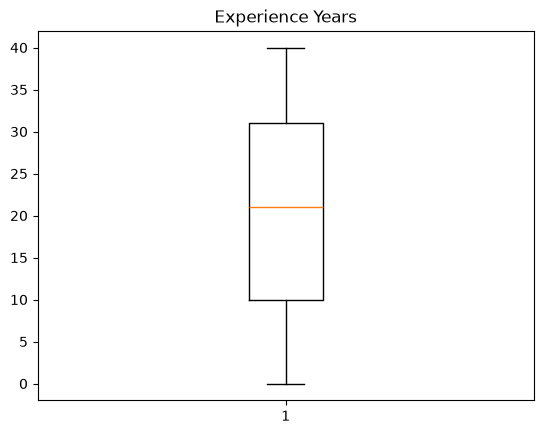

In [17]:
import matplotlib.pyplot as plt

plt.boxplot(df_clean["Experience_Years"])
plt.title("Experience Years")
plt.show()

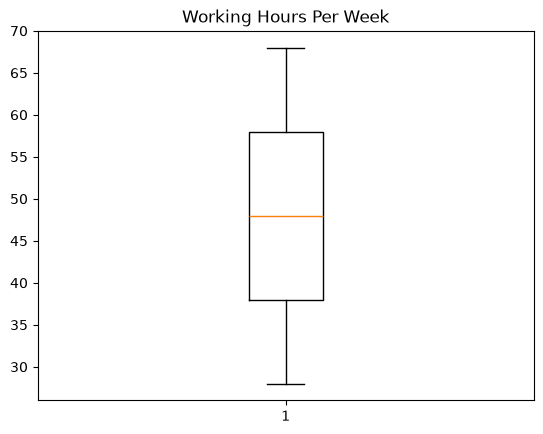

In [18]:
plt.boxplot(df_clean["Working_Hours_Per_Week"])
plt.title("Working Hours Per Week")
plt.show()

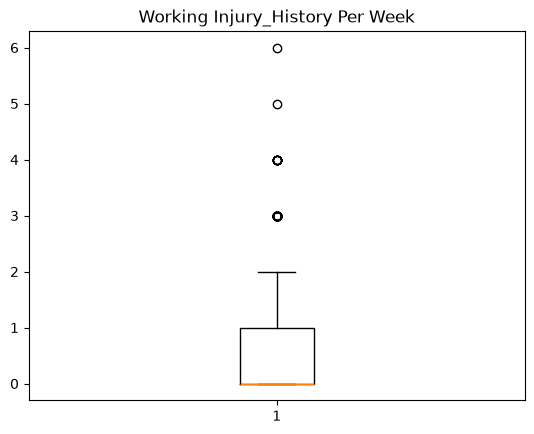

In [19]:
plt.boxplot(df_clean["Injury_History"])
plt.title("Working Injury_History Per Week")
plt.show()

In [20]:
Q1 = df_clean["Injury_History"].quantile(0.25)
Q3 = df_clean["Injury_History"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[
    (df_clean["Injury_History"] < lower) |
    (df_clean["Injury_History"] > upper)
]

print(outliers.shape)

print(f"Detected Outliers: {len(outliers)}")
outliers["Injury_History"].value_counts().sort_index()

(54, 14)
Detected Outliers: 54


Injury_History
3    44
4     8
5     1
6     1
Name: count, dtype: int64

## Task 05 Explanation
I analyzed the numerical columns using summary statistics, box plots, and the IQR method. No outliers were found in the Experience_Years and Working_Hours_Per_Week columns. The IQR method identified 54 statistical outliers in the Injury_History column. However, these values represent the number of workplace injuries and are realistic according to the domain context. Since they are valid observations rather than data entry errors, no outlier treatment was applied and the original values were retained.

## Task 06: Noisy Data Detection

In [21]:
# for col in df_clean.select_dtypes(include='object'):
#     print(f"\n{col}")
#     print(df_clean[col].value_counts())

# checking validity
min_age = 0
max_age = 40

df_clean[df_clean['Experience_Years'] < min_age]
df_clean[df_clean['Experience_Years'] > max_age]

min_hour = 28
max_hour = 68
df_clean[df_clean['Working_Hours_Per_Week'] < min_hour]
df_clean[df_clean['Working_Hours_Per_Week'] > max_hour]

min_injury = 0
max_injury = 6
df_clean[df_clean['Injury_History'] < min_injury]
df_clean[df_clean['Injury_History'] > max_injury]

,Name,Garment_Name,Experience_Years,Job_Role,Working_Hours_Per_Week,Exposure_To_Chemicals,Machine_Use,Workstation_Ergonomics,Injury_History,Health_Condition,Safety_Training,Shift_Type,Task_Rotation_Frequency,Job_Risk


## Task 06 Explanation
I first inspected the categorical columns using value_counts() to check for noisy values such as unexpected labels, typing mistakes, or irrelevant entries. The inspection showed that all categorical values were meaningful and consistently formatted.

Next, I validated the numerical columns using rule-based filtering. I checked whether Experience_Years falls within the valid range of 0 to 40, Working_Hours_Per_Week within 28 to 68, and Injury_History within 0 to 6. Boolean filtering confirmed that no records violated these expected ranges.

Since no noisy or invalid values were found in either the categorical or numerical columns, no filtering or correction was required.

Finally, the dataset was verified and confirmed to contain only valid and meaningful values, making it suitable for further analysis and machine learning tasks.

## Task 07 : Data Type Consistency Check

In [22]:
df_clean.dtypes

print("Categorical Columns:")
print(df_clean.select_dtypes(include='str').columns)

print("\nNumeric Columns:")
print(df_clean.select_dtypes(include='int64').columns)

Categorical Columns:
Index(['Name', 'Garment_Name', 'Job_Role', 'Exposure_To_Chemicals',
       'Machine_Use', 'Workstation_Ergonomics', 'Health_Condition',
       'Safety_Training', 'Shift_Type', 'Task_Rotation_Frequency', 'Job_Risk'],
      dtype='str')

Numeric Columns:
Index(['Experience_Years', 'Working_Hours_Per_Week', 'Injury_History'], dtype='str')


## Task 07 Explanation

I checked the data types of all columns using df_clean.dtypes to verify that each feature is stored using an appropriate data type. I also separated the categorical and numerical columns using select_dtypes() to confirm their consistency.

The inspection showed that all categorical features are stored as string data types, while all numerical features are stored as integer data types. No columns were found with incorrect or inconsistent data types.

Since all features already use appropriate data types, no type conversion was required. The dataset is therefore consistent and ready for further preprocessing and analysis.

Result:

All categorical columns have appropriate string data types.
All numerical columns have appropriate integer data types.
No data type inconsistencies were found.
No data type conversion was required.

## Task 08 : Schema Validation

In [23]:
required_cols = [
    "Name",
    "Garment_Name",
    "Experience_Years",
    "Job_Role",
    "Working_Hours_Per_Week",
    "Exposure_To_Chemicals",
    "Machine_Use",
    "Workstation_Ergonomics",
    "Injury_History",
    "Health_Condition",
    "Safety_Training",
    "Shift_Type",
    "Task_Rotation_Frequency",
    "Job_Risk"
]

missing = set(required_cols) - set(df_clean.columns)
extra = set(df_clean.columns) - set(required_cols)

print("Missing Columns:", missing)
print("Extra Columns:", extra)

Missing Columns: set()
Extra Columns: set()


## Task 08 Explanation

I validated the dataset schema by comparing the current column names with a predefined list of expected columns. Using set operations, I checked for both missing and unexpected columns in the dataset.

The validation showed that there are no missing columns and no extra columns. All required features are present, and the column names match the expected schema.

Since the dataset already follows the required structure, no schema modifications were necessary.

Result:

No missing columns were found.
No extra columns were found.
All column names match the expected schema.
The dataset schema is valid and ready for further preprocessing and analysis.

## Task 09: Data Range Validation

In [24]:
min_exp = 0
max_exp = 40

min_hours = 28
max_hours = 68

min_injury = 0
max_injury = 6

df_clean[
    (df_clean["Experience_Years"] < min_exp) | (df_clean["Experience_Years"] > max_exp)
]

df_clean[
    (df_clean["Working_Hours_Per_Week"] < min_hours) | (df_clean["Working_Hours_Per_Week"] > max_hours)
]

df_clean[
    (df_clean["Injury_History"] < min_injury) | (df_clean["Injury_History"] > max_injury)
]

,Name,Garment_Name,Experience_Years,Job_Role,Working_Hours_Per_Week,Exposure_To_Chemicals,Machine_Use,Workstation_Ergonomics,Injury_History,Health_Condition,Safety_Training,Shift_Type,Task_Rotation_Frequency,Job_Risk


## Task 09 Explanation

I validated the numerical columns using predefined business rules to ensure that all values fall within acceptable ranges. The Experience_Years column was checked to ensure values are between 0 and 40, Working_Hours_Per_Week between 28 and 68, and Injury_History between 0 and 6. Boolean filtering confirmed that no records violated these ranges. Since all values were already within their expected limits, no corrections or filtering were required. The dataset satisfies the defined domain rules and is ready for further analysis.

## Task 10

In [25]:
df_clean["Job_Risk"].value_counts()
df_clean["Job_Risk"].value_counts(normalize=True) * 100

Job_Risk
Low       42.0
Medium    36.0
High      22.0
Name: proportion, dtype: float64

In [26]:
## Oversampling

from sklearn.utils import resample

low = df_clean[df_clean["Job_Risk"] == "Low"]
medium = df_clean[df_clean["Job_Risk"] == "Medium"]
high = df_clean[df_clean["Job_Risk"] == "High"]

# Largest class size
max_size = df_clean["Job_Risk"].value_counts().max()

medium_up = resample(
    medium,
    replace=True,
    n_samples=max_size,
    random_state=42
)

high_up = resample(
    high,
    replace=True,
    n_samples=max_size,
    random_state=42
)

df_balanced = pd.concat([low, medium_up, high_up])

print(df_balanced["Job_Risk"].value_counts())

Job_Risk
Low       1050
Medium    1050
High      1050
Name: count, dtype: int64


In [27]:
## Undersampling

from sklearn.utils import resample

low_down = resample(
    low,
    replace=False,
    n_samples=len(high),
    random_state=42
)

medium_down = resample(
    medium,
    replace=False,
    n_samples=len(high),
    random_state=42
)

df_under = pd.concat([low_down, medium_down, high])

print(df_under["Job_Risk"].value_counts())

Job_Risk
Low       550
Medium    550
High      550
Name: count, dtype: int64


In [28]:
## Smote
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

df_temp = df_clean.copy()

le = LabelEncoder()
df_temp["Job_Risk"] = le.fit_transform(df_temp["Job_Risk"])

X = pd.get_dummies(df_temp.drop("Job_Risk", axis=1))
y = df_temp["Job_Risk"]

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print(pd.Series(y_resampled).value_counts())

Job_Risk
1    1050
2    1050
0    1050
Name: count, dtype: int64


## Note: The original dataset was reasonably balanced (42%, 36%, 22%), so resampling techniques were demonstrated for learning purposes only and were not required for this dataset.

## Task 10 Explanation

I examined the distribution of the target variable Job_Risk using value_counts() and percentage analysis. The dataset contains three classes (Low, Medium, and High) with proportions of approximately 42%, 36%, and 22%, respectively. Although the dataset is reasonably balanced, the High class has comparatively fewer samples.

To demonstrate how class imbalance can be handled in machine learning, I applied Oversampling to increase the number of minority class samples and create a balanced class distribution. This technique helps reduce model bias toward majority classes and improves learning when significant imbalance exists.

Result:

Target class distribution was analyzed.
The dataset is moderately balanced and suitable for training.
Oversampling was demonstrated for learning purposes.
The balanced dataset can be used if equal class representation is required for model training.

In [29]:
df_clean.to_csv("Garment_Job_Risk_CLEANED")